# 09 — Batch-test av referensbilder mot 3-klassmodellen
Kör hela `reference_test_images`-mappen genom samma pipeline som `app_3class.py` (MTCNN-crop + mustasch-grind + 3-klass epic-modell + den slutgiltiga scoring-formeln) och visar allt i en tabell, så hela spannet kan bedömas i ett svep.

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from facenet_pytorch import MTCNN

mtcnn = MTCNN(image_size=178, margin=40, post_process=False)

mustache_model = tf.keras.models.load_model('models/mustache_detector_3.keras')
epic_model     = tf.keras.models.load_model('models/epic_detector_3class.keras')

CLASS_NAMES = ['epic', 'medium', 'thin']
REF_DIR = 'data/reference_test_images'

print('Modeller laddade.')

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Modeller laddade.


## Samma helper-funktioner som i app_3class.py
Kopierat rakt av för att garantera att batch-testet och appen beter sig identiskt.

In [3]:
def prepare_image(image):
    image = image.convert('RGB')
    face = mtcnn(image)
    if face is not None:
        arr = face.permute(1, 2, 0).numpy().astype(np.uint8)
    else:
        arr = np.array(image.resize((178, 178)))
    return np.expand_dims(arr, axis=0)


def weighted_epic_score(p_epic, p_medium, p_thin):
    p_max = max(p_epic, p_medium, p_thin)

    if p_epic == p_max:
        score = p_epic * 100 + p_medium * 50 - p_thin * 100
    elif p_medium == p_max:
        score = p_medium * 60 + p_epic * 40 - p_thin * 60
    else:
        score = p_thin * 8 + p_epic * 100 + p_medium * 50

    if p_max < 0.7:
        score *= 0.92

    return float(np.clip(score, 0, 100))


def classify_epicness(score):
    if score >= 95:
        return 'LEGENDARY'
    elif score >= 65:
        return 'Distinguished'
    elif score >= 45:
        return 'Standard Issue'
    elif score >= 25:
        return 'Apprentice'
    else:
        return 'Fjunig'

## Kör batch-testet

In [4]:
image_paths = sorted(
    glob.glob(os.path.join(REF_DIR, '*.jpg')) +
    glob.glob(os.path.join(REF_DIR, '*.jpeg')) +
    glob.glob(os.path.join(REF_DIR, '*.png'))
)

print(f'Hittade {len(image_paths)} referensbilder.')

rows = []

for path in image_paths:
    img = Image.open(path)
    arr = prepare_image(img)

    mustache_prob = float(mustache_model.predict(arr, verbose=0)[0][0])

    if mustache_prob < 0.4:
        rows.append({
            'filnamn': os.path.basename(path),
            'sökväg': path,
            'mustache_prob': round(mustache_prob, 3),
            'p_epic': None,
            'p_medium': None,
            'p_thin': None,
            'epic_score': None,
            'kategori': 'INGEN MUSTASCH'
        })
        continue

    preds = epic_model.predict(arr, verbose=0)[0]
    p_epic, p_medium, p_thin = float(preds[0]), float(preds[1]), float(preds[2])
    score = weighted_epic_score(p_epic, p_medium, p_thin)

    rows.append({
        'filnamn': os.path.basename(path),
        'sökväg': path,
        'mustache_prob': round(mustache_prob, 3),
        'p_epic': round(p_epic, 3),
        'p_medium': round(p_medium, 3),
        'p_thin': round(p_thin, 3),
        'epic_score': round(score, 1),
        'kategori': classify_epicness(score)
    })

df = pd.DataFrame(rows)
df = df.sort_values('epic_score', ascending=False, na_position='last').reset_index(drop=True)

pd.set_option('display.max_rows', None)
df.drop(columns=['sökväg'])

Hittade 41 referensbilder.


,filnamn,mustache_prob,p_epic,p_medium,p_thin,epic_score,kategori
0,160030.png,1.000,1.000,0.000,0.000,100.0,LEGENDARY
1,16008.png,1.000,1.000,0.000,0.000,100.0,LEGENDARY
2,160013.png,1.000,1.000,0.000,0.000,100.0,LEGENDARY
3,160046.png,1.000,1.000,0.000,0.000,100.0,LEGENDARY
4,160024.png,1.000,1.000,0.000,0.000,100.0,LEGENDARY
5,160039.png,1.000,1.000,0.000,0.000,100.0,LEGENDARY
6,160020.png,1.000,0.997,0.003,0.000,99.8,LEGENDARY
7,160025.png,1.000,0.993,0.007,0.000,99.6,LEGENDARY
8,160019.png,1.000,0.983,0.016,0.001,99.0,LEGENDARY
9,160031.png,1.000,0.963,0.037,0.001,98.0,LEGENDARY


## Översikt — fördelning över kategorier

In [5]:
print(df['kategori'].value_counts())
print()
print('Medel epic_score (exkl. "INGEN MUSTASCH"):', df['epic_score'].mean())

kategori
Distinguished     12
LEGENDARY         11
Fjunig             7
Standard Issue     6
Apprentice         3
INGEN MUSTASCH     2
Name: count, dtype: int64

Medel epic_score (exkl. "INGEN MUSTASCH"): 67.8


## Visa bilderna som fick exakt 100.0
Snabb visuell sanity check — är de här verkligen legendariska, eller har något smitit igenom?

6 bilder med epic_score = 100.0


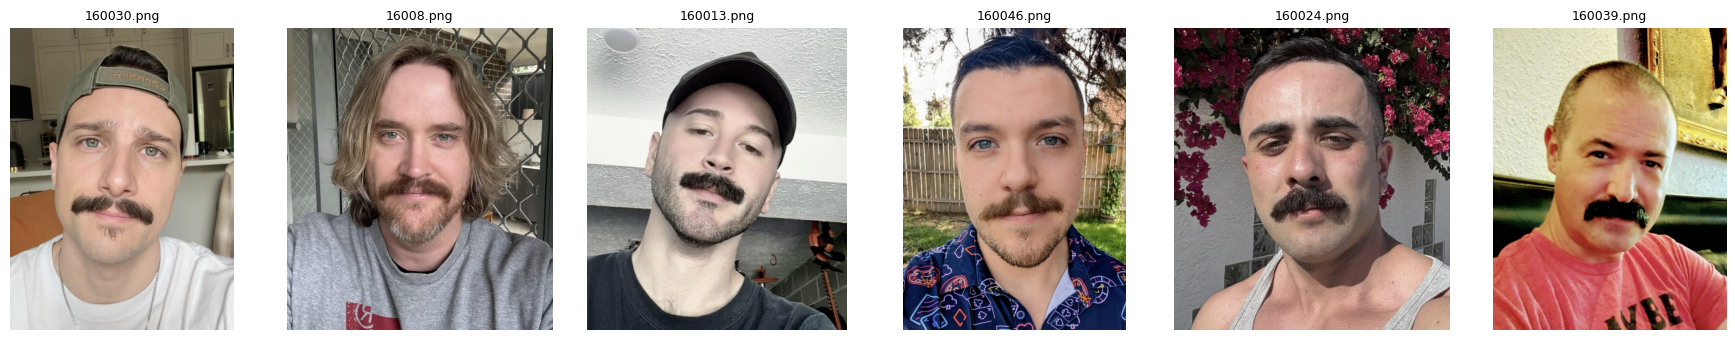

In [6]:
import matplotlib.pyplot as plt

perfect = df[df['epic_score'] == 100.0]
print(f'{len(perfect)} bilder med epic_score = 100.0')

n = len(perfect)
cols = min(n, 6)
rows_needed = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_needed, cols, figsize=(3 * cols, 3.5 * rows_needed))
axes = axes.flatten() if n > 1 else [axes]

for ax, (_, row) in zip(axes, perfect.iterrows()):
    img = Image.open(row['sökväg'])
    ax.imshow(img)
    ax.set_title(row['filnamn'], fontsize=9)
    ax.axis('off')

for ax in axes[len(perfect):]:
    ax.axis('off')

plt.tight_layout()
plt.show()